# Model Comparison: Ridge vs XGBoost vs GIN vs GAT

Loads saved test-set predictions from `02_ridge_model`, `03_boosting_model`, `04_gin_model`, and `05_gat_model` and compares their performance.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

plt.style.use("ggplot")

In [2]:
ridge = pl.read_parquet("../data/predictions/ridge_predictions.parquet")
xgb   = pl.read_parquet("../data/predictions/xgb_predictions.parquet")
gin   = pl.read_parquet("../data/predictions/gin_predictions.parquet")
gat   = pl.read_parquet("../data/predictions/gat_predictions.parquet")

print(f"Ridge   test samples: {len(ridge)}")
print(f"XGBoost test samples: {len(xgb)}")
print(f"GIN     test samples: {len(gin)}")
print(f"GAT     test samples: {len(gat)}")

Ridge   test samples: 609
XGBoost test samples: 609
GIN     test samples: 609
GAT     test samples: 609


In [3]:
def eval_metrics(df):
    mae  = mean_absolute_error(df["y_true"], df["y_pred"])
    rmse = root_mean_squared_error(df["y_true"], df["y_pred"])
    return mae, rmse

ridge_mae, ridge_rmse = eval_metrics(ridge)
xgb_mae,   xgb_rmse   = eval_metrics(xgb)
gin_mae,   gin_rmse   = eval_metrics(gin)
gat_mae,   gat_rmse   = eval_metrics(gat)

print(f"Ridge   — MAE: {ridge_mae:.2f} °C   RMSE: {ridge_rmse:.2f} °C")
print(f"XGBoost — MAE: {xgb_mae:.2f} °C   RMSE: {xgb_rmse:.2f} °C")
print(f"GIN     — MAE: {gin_mae:.2f} °C   RMSE: {gin_rmse:.2f} °C")
print(f"GAT     — MAE: {gat_mae:.2f} °C   RMSE: {gat_rmse:.2f} °C")

Ridge   — MAE: 40.26 °C   RMSE: 54.59 °C
XGBoost — MAE: 28.60 °C   RMSE: 38.56 °C
GIN     — MAE: 26.86 °C   RMSE: 36.28 °C
GAT     — MAE: 25.99 °C   RMSE: 34.86 °C


## Error Comparison

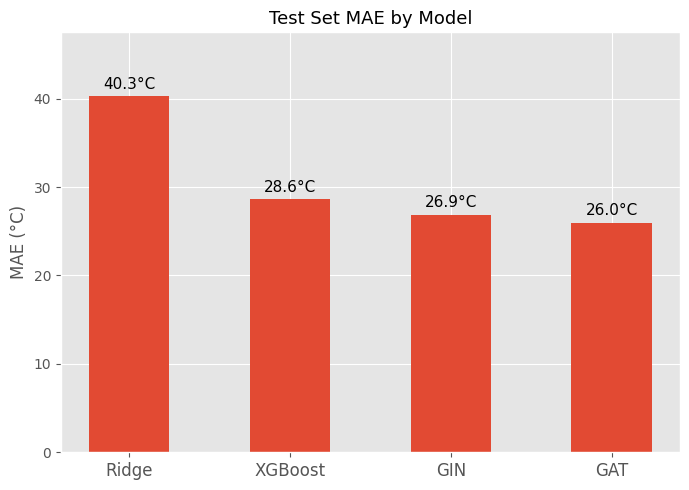

In [4]:
model_names = ["Ridge", "XGBoost", "GIN", "GAT"]
maes        = [ridge_mae, xgb_mae, gin_mae, gat_mae]

x      = np.arange(len(model_names))
width  = 0.5

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(x, maes, width, linewidth=0.8)

for bar in bars:
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.5,
        f"{bar.get_height():.1f}°C",
        ha="center", va="bottom", fontsize=11,
    )

ax.set_xticks(x)
ax.set_xticklabels(model_names, fontsize=12)
ax.set_ylabel("MAE (°C)", fontsize=12)
ax.set_title("Test Set MAE by Model", fontsize=13)
ax.set_ylim(0, max(maes) * 1.18)
plt.tight_layout()
plt.savefig("../img/test_set_error.png", dpi=150)
plt.show()

## Predicted vs Actual

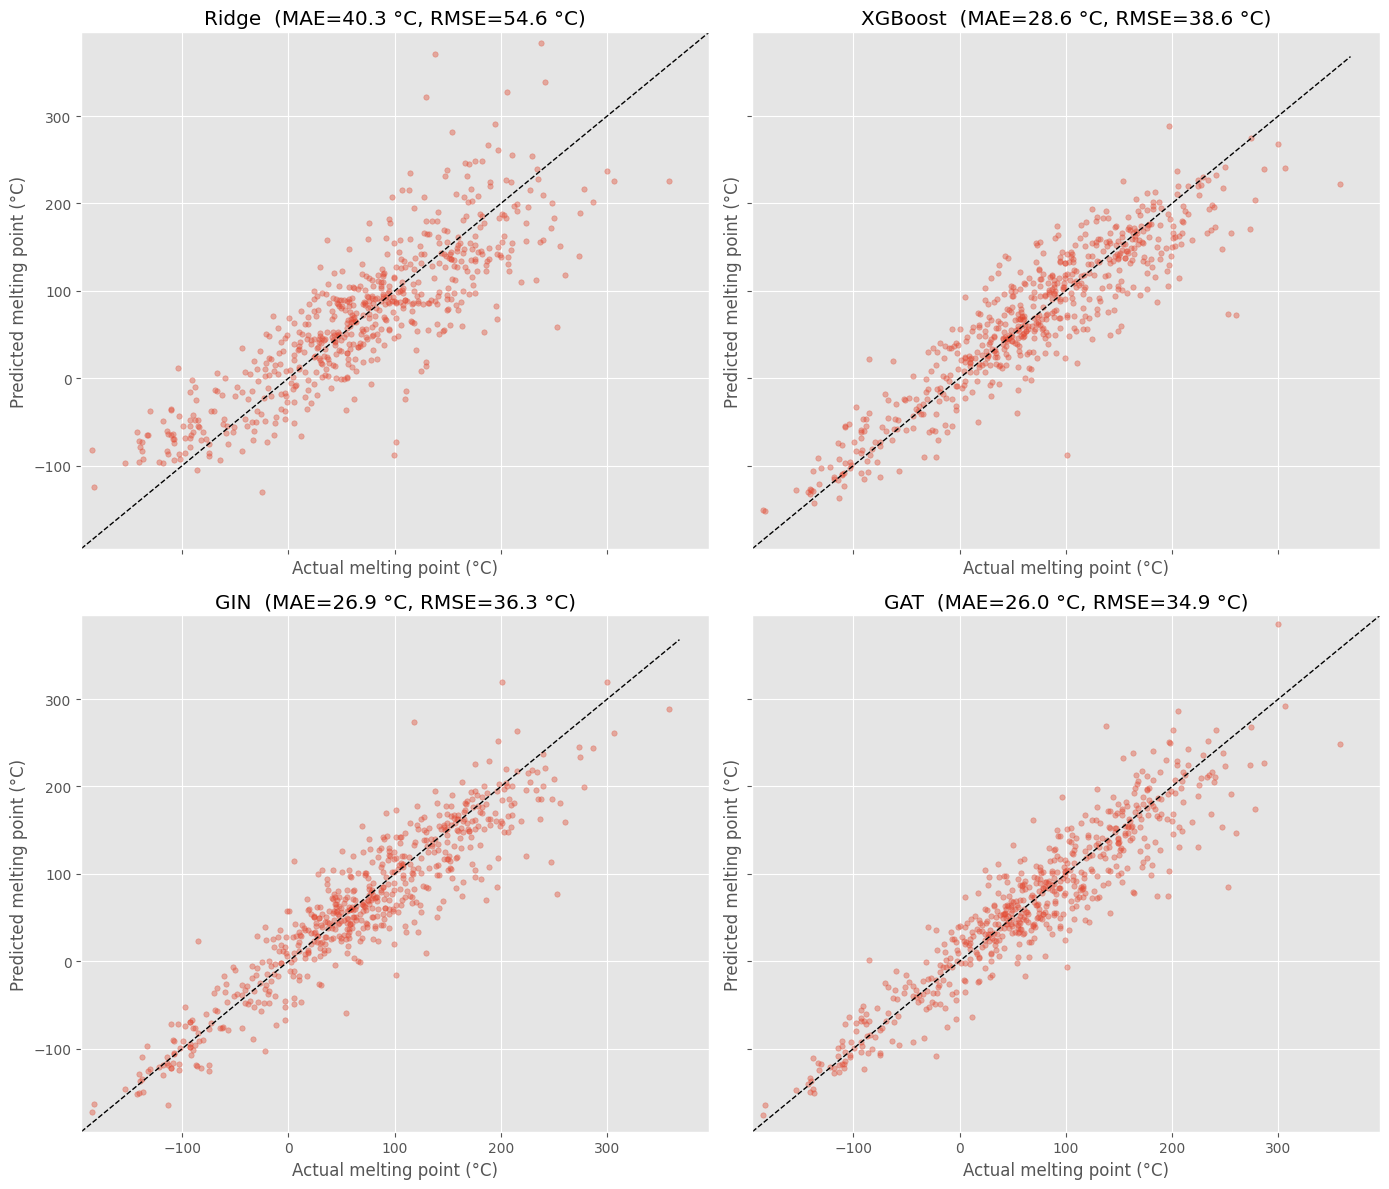

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 12), sharex=True, sharey=True)

for ax, df, name, mae, rmse in [
    (axes[0, 0], ridge, "Ridge",   ridge_mae, ridge_rmse),
    (axes[0, 1], xgb,   "XGBoost", xgb_mae,   xgb_rmse),
    (axes[1, 0], gin,   "GIN",     gin_mae,   gin_rmse),
    (axes[1, 1], gat,   "GAT",     gat_mae,   gat_rmse),
]:
    true = df["y_true"].to_numpy()
    pred = df["y_pred"].to_numpy()
    lims = [min(true.min(), pred.min()) - 10, max(true.max(), pred.max()) + 10]
    ax.scatter(true, pred, alpha=0.4, s=15)
    ax.plot(lims, lims, "k--", linewidth=1)
    ax.set_xlim(lims)
    ax.set_ylim(lims)
    ax.set_xlabel("Actual melting point (°C)")
    ax.set_ylabel("Predicted melting point (°C)")
    ax.set_title(f"{name}  (MAE={mae:.1f} °C, RMSE={rmse:.1f} °C)")

plt.tight_layout()
plt.savefig("../img/actual_vs_pred_mp.png")
plt.show()